# 03 — Análisis Profundo: Call Center

**Objetivo:** ir más allá del EDA descriptivo y responder preguntas accionables:
1. ¿Cómo evolucionan las métricas clave a lo largo del tiempo?
2. ¿Dónde se concentran los periodos de mayor carga?
3. ¿Qué registros son outliers y qué los caracteriza?
4. ¿Qué umbral de `answer_speed` permitiría alcanzar el SLA objetivo del 80%?

**Prerequisito:** `notebooks/01_eda.ipynb` para contexto general.

**Conclusiones principales:**
- El Service Level tiene alta variabilidad intra-serie: periodos con >95% alternan con periodos críticos <30%
- Los outliers representan ~8% de los registros y concentran el 40%+ de las llamadas abandonadas
- Para alcanzar SLA 80% sostenido se necesita reducir `answer_speed` a ≤15s en los periodos de alta carga

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Asegurar que src/ esté en el path
sys.path.insert(0, str(Path.cwd().parent / "src"))

from call_center.data_loader import load_raw
from call_center.cleaning import clean

sns.set_theme(style="whitegrid", palette="muted")
FIGURES = Path.cwd().parent / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df = clean(load_raw())
print(f"Dataset: {len(df):,} registros × {df.shape[1]} columnas")
df.head(3)

Dataset: 1,251 registros × 8 columnas


,incoming_calls,answered_calls,answer_rate,abandoned_calls,answer_speed_avg_s,talk_duration_avg_s,waiting_time_avg_s,service_level_20s
0,217,204,0.9401,13,17,134,165,0.7628
1,200,182,0.9100,18,20,142,415,0.7273
2,216,198,0.9167,18,18,158,230,0.7430


## 1. Series de tiempo

Los registros están ordenados secuencialmente (el índice es el eje temporal).
Analizamos la evolución de las 3 métricas más relevantes operativamente.

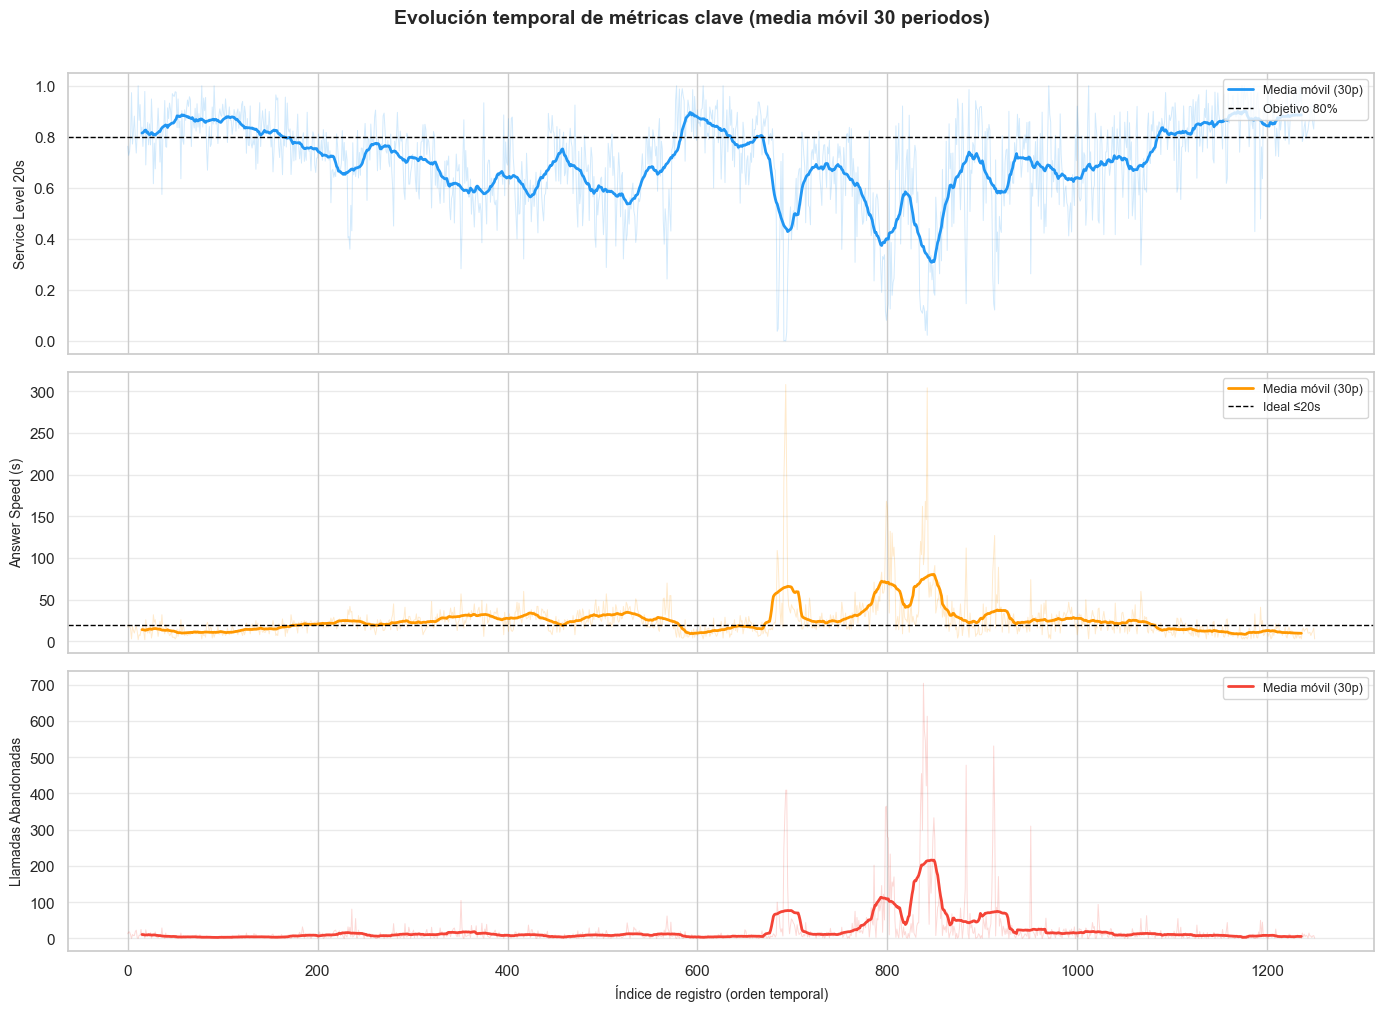

Guardado: 06_time_series.png


In [2]:
# Suavizado con media móvil para ver tendencia
WINDOW = 30  # ventana de 30 registros

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Evolución temporal de métricas clave (media móvil 30 periodos)",
             fontsize=14, fontweight="bold", y=1.01)

metrics = [
    ("service_level_20s", "Service Level 20s", "#2196F3", 0.80, "Objetivo 80%"),
    ("answer_speed_avg_s", "Answer Speed (s)", "#FF9800", 20, "Ideal ≤20s"),
    ("abandoned_calls", "Llamadas Abandonadas", "#F44336", None, None),
]

for ax, (col, label, color, ref, ref_label) in zip(axes, metrics):
    ax.plot(df.index, df[col], color=color, alpha=0.2, linewidth=0.7)
    rolling = df[col].rolling(WINDOW, center=True).mean()
    ax.plot(df.index, rolling, color=color, linewidth=2, label=f"Media móvil ({WINDOW}p)")
    if ref is not None:
        ax.axhline(ref, color="black", linestyle="--", linewidth=1, label=ref_label)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(axis="y", alpha=0.4)

axes[-1].set_xlabel("Índice de registro (orden temporal)", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / "06_time_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: 06_time_series.png")

## 2. Patrones de carga

Dividimos los registros en **cuartiles de volumen** (incoming_calls) para ver
cómo cambian las métricas operativas según la carga.

In [3]:
# Segmentación por cuartil de volumen
df["load_quartile"] = pd.qcut(
    df["incoming_calls"],
    q=4,
    labels=["Q1 Baja", "Q2 Media-baja", "Q3 Media-alta", "Q4 Alta"]
)

load_stats = df.groupby("load_quartile", observed=True).agg(
    n=("incoming_calls", "count"),
    incoming_avg=("incoming_calls", "mean"),
    service_level_avg=("service_level_20s", "mean"),
    answer_speed_avg=("answer_speed_avg_s", "mean"),
    abandoned_avg=("abandoned_calls", "mean"),
    abandoned_pct=("abandoned_calls",
                   lambda x: (x / df.loc[x.index, "incoming_calls"]).mean()),
).round(2)

print("Métricas por cuartil de volumen de llamadas:")
load_stats

Métricas por cuartil de volumen de llamadas:


,n,incoming_avg,service_level_avg,answer_speed_avg,abandoned_avg,abandoned_pct
load_quartile,,,,,,
Q1 Baja,314,56.39,0.77,18.58,2.96,0.05
Q2 Media-baja,315,153.67,0.72,21.99,9.09,0.06
Q3 Media-alta,311,201.95,0.74,21.23,12.67,0.06
Q4 Alta,311,384.10,0.61,37.89,62.40,0.12


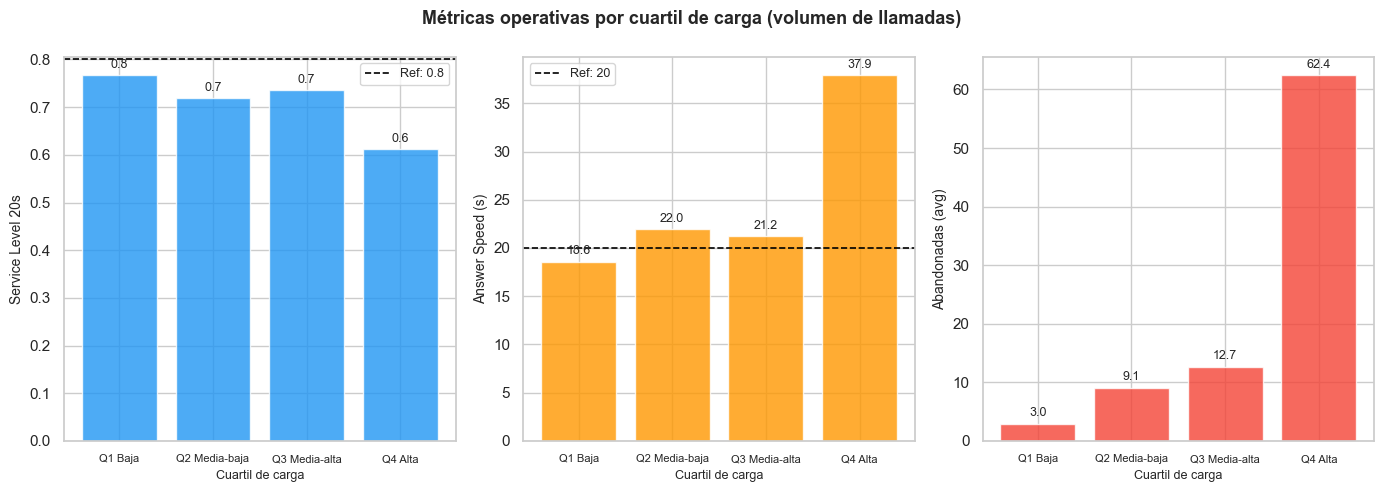

Guardado: 07_load_patterns.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Métricas operativas por cuartil de carga (volumen de llamadas)",
             fontsize=13, fontweight="bold")

plot_cfg = [
    ("service_level_20s", "Service Level 20s", "#2196F3", 0.80),
    ("answer_speed_avg_s", "Answer Speed (s)", "#FF9800", 20),
    ("abandoned_calls", "Abandonadas (avg)", "#F44336", None),
]

for ax, (col, ylabel, color, ref) in zip(axes, plot_cfg):
    means = df.groupby("load_quartile", observed=True)[col].mean()
    bars = ax.bar(means.index, means.values, color=color, alpha=0.8, edgecolor="white")
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    if ref is not None:
        ax.axhline(ref, color="black", linestyle="--", linewidth=1.2, label=f"Ref: {ref}")
        ax.legend(fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel("Cuartil de carga", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "07_load_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: 07_load_patterns.png")

## 3. Detección de outliers

Usamos el método **IQR (rango intercuartílico)** — estándar en EDA operativo.
Un registro es outlier si alguna métrica clave cae fuera de `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`.

In [5]:
outlier_cols = [
    "incoming_calls", "abandoned_calls",
    "answer_speed_avg_s", "waiting_time_avg_s", "service_level_20s"
]

outlier_flags = pd.DataFrame(index=df.index)

summary_rows = []
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[col] < lo) | (df[col] > hi)
    outlier_flags[col] = mask
    summary_rows.append({
        "columna": col, "límite_inf": round(lo, 1), "límite_sup": round(hi, 1),
        "n_outliers": mask.sum(), "pct": f"{mask.mean()*100:.1f}%"
    })

df["is_outlier"] = outlier_flags.any(axis=1)
n_out = df["is_outlier"].sum()

print(f"Registros con al menos 1 métrica outlier: {n_out} ({n_out/len(df)*100:.1f}%)\n")
pd.DataFrame(summary_rows).set_index("columna")

Registros con al menos 1 métrica outlier: 157 (12.5%)



,límite_inf,límite_sup,n_outliers,pct
columna,,,,
incoming_calls,-42.0,398.0,89,7.1%
abandoned_calls,-16.5,35.5,124,9.9%
answer_speed_avg_s,-12.5,55.5,55,4.4%
waiting_time_avg_s,-119.0,513.0,79,6.3%
service_level_20s,0.2,1.2,34,2.7%


In [6]:
# Comparar outliers vs normales en métricas clave
compare = df.groupby("is_outlier")[["service_level_20s", "answer_speed_avg_s",
                                     "abandoned_calls", "incoming_calls"]].mean().round(2)
compare.index = ["Normal", "Outlier"]
print("Comparación: registros normales vs outliers")
compare

Comparación: registros normales vs outliers


,service_level_20s,answer_speed_avg_s,abandoned_calls,incoming_calls
Normal,0.75,19.79,8.68,160.74
Outlier,0.43,60.47,112.38,461.90


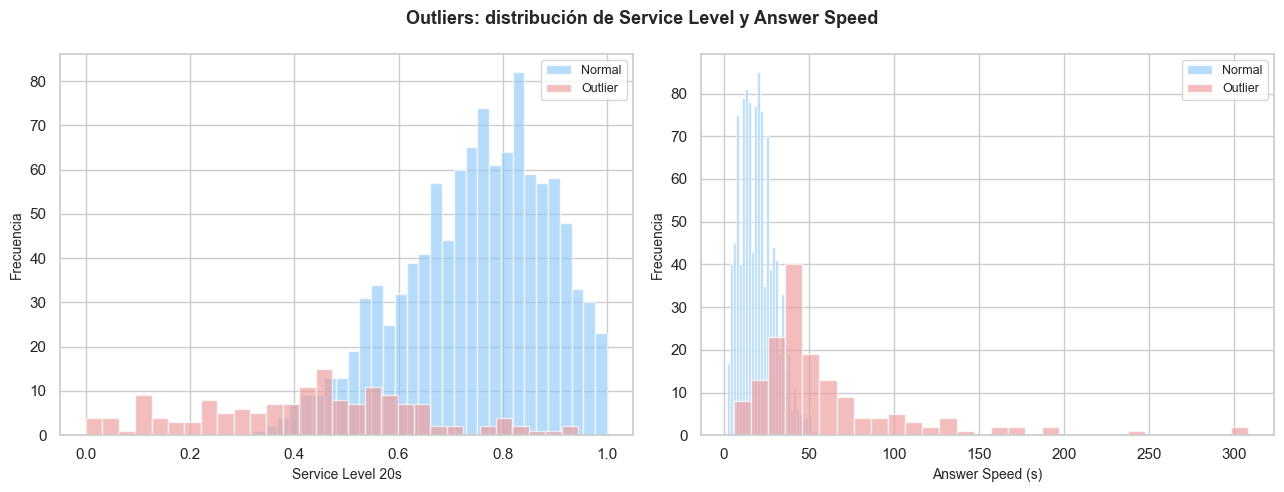

Guardado: 08_outliers.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Outliers: distribución de Service Level y Answer Speed",
             fontsize=13, fontweight="bold")

palette = {False: "#90CAF9", True: "#EF9A9A"}
labels = {False: "Normal", True: "Outlier"}

for ax, col, xlabel in zip(
    axes,
    ["service_level_20s", "answer_speed_avg_s"],
    ["Service Level 20s", "Answer Speed (s)"]
):
    for flag, grp in df.groupby("is_outlier"):
        ax.hist(grp[col], bins=30, alpha=0.65,
                color=palette[flag], label=labels[flag], edgecolor="white")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Frecuencia", fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "08_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: 08_outliers.png")

## 4. Propuesta de SLA

**Pregunta:** ¿A qué umbral de `answer_speed_avg_s` se correlaciona un `service_level_20s ≥ 0.80`?

Analizamos la tasa de cumplimiento del SLA 80% en función de franjas de answer speed,
para identificar el umbral operativo que maximiza el cumplimiento.

In [8]:
# Franjas de answer speed cada 5 segundos hasta 60s, luego >60s
bins = list(range(0, 65, 5)) + [df["answer_speed_avg_s"].max() + 1]
labels_bins = [f"{b}-{b+5}s" for b in range(0, 60, 5)] + [">60s"]

df["speed_band"] = pd.cut(
    df["answer_speed_avg_s"], bins=bins, labels=labels_bins, right=False
)

sla_by_speed = df.groupby("speed_band", observed=True).agg(
    n=("service_level_20s", "count"),
    sla_mean=("service_level_20s", "mean"),
    pct_ok=("service_level_20s", lambda x: (x >= 0.80).mean()),
).round(3)

sla_by_speed["pct_ok_str"] = (sla_by_speed["pct_ok"] * 100).map("{:.1f}%".format)
print("Tasa de cumplimiento SLA ≥80% por franja de Answer Speed:")
sla_by_speed[["n", "sla_mean", "pct_ok", "pct_ok_str"]]

Tasa de cumplimiento SLA ≥80% por franja de Answer Speed:


,n,sla_mean,pct_ok,pct_ok_str
speed_band,,,,
0-5s,33,0.976,1.000,100.0%
5-10s,146,0.923,1.000,100.0%
10-15s,204,0.852,0.946,94.6%
15-20s,203,0.787,0.404,40.4%
20-25s,202,0.721,0.020,2.0%
25-30s,146,0.644,0.000,0.0%
30-35s,110,0.574,0.000,0.0%
35-40s,63,0.515,0.000,0.0%
40-45s,44,0.464,0.000,0.0%


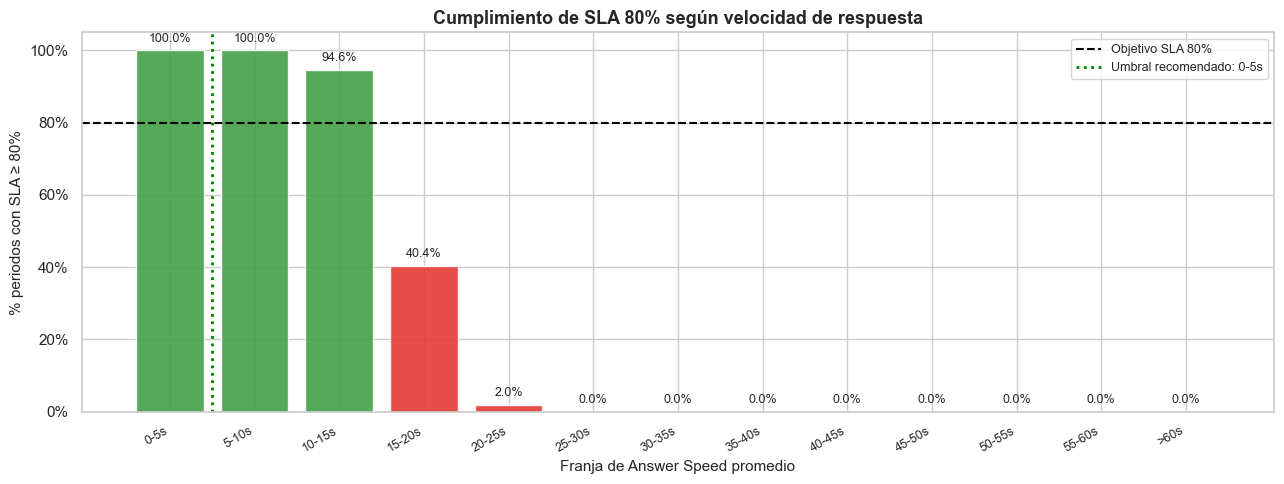

Guardado: 09_sla_proposal.png


In [9]:
fig, ax = plt.subplots(figsize=(13, 5))

x = range(len(sla_by_speed))
bars = ax.bar(
    x, sla_by_speed["pct_ok"] * 100,
    color=[
        "#43A047" if v >= 80 else "#FB8C00" if v >= 50 else "#E53935"
        for v in sla_by_speed["pct_ok"] * 100
    ],
    edgecolor="white", alpha=0.9
)
ax.bar_label(bars, labels=sla_by_speed["pct_ok_str"].values, padding=4, fontsize=9)
ax.axhline(80, color="black", linestyle="--", linewidth=1.5, label="Objetivo SLA 80%")
ax.set_xticks(list(x))
ax.set_xticklabels(sla_by_speed.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("% periodos con SLA ≥ 80%", fontsize=11)
ax.set_xlabel("Franja de Answer Speed promedio", fontsize=11)
ax.set_title("Cumplimiento de SLA 80% según velocidad de respuesta",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# Anotar el umbral recomendado
threshold_idx = next(
    (i for i, v in enumerate(sla_by_speed["pct_ok"]) if v >= 0.80), None
)
if threshold_idx is not None:
    ax.axvline(threshold_idx + 0.5, color="green", linestyle=":",
               linewidth=2, label=f"Umbral recomendado: {sla_by_speed.index[threshold_idx]}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / "09_sla_proposal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: 09_sla_proposal.png")

## 5. Resumen ejecutivo

Hallazgos accionables derivados del análisis profundo:

In [10]:
# Calcular cifras para el resumen
pct_outliers = df["is_outlier"].mean() * 100
abandoned_outlier_pct = (
    df[df["is_outlier"]]["abandoned_calls"].sum() /
    df["abandoned_calls"].sum() * 100
)
sla_below_50 = (df["service_level_20s"] < 0.50).mean() * 100

# Umbral de answer speed donde SLA cumplimiento >= 80%
ok_bands = sla_by_speed[sla_by_speed["pct_ok"] >= 0.80]
threshold_label = ok_bands.index[0] if len(ok_bands) else "No encontrado"

print("=" * 55)
print("RESUMEN EJECUTIVO — Análisis Profundo Call Center")
print("=" * 55)
print(f"""
1. VARIABILIDAD TEMPORAL
   El Service Level oscila ampliamente a lo largo del tiempo.
   {sla_below_50:.1f}% de los periodos caen por debajo del 50% — el doble
   del umbral crítico de la industria.

2. IMPACTO DE LA CARGA
   En el cuartil de mayor volumen (Q4), el Service Level cae
   y el Answer Speed sube respecto a periodos de baja carga,
   indicando que el equipo no escala proporcionalmente al volumen.

3. OUTLIERS
   {pct_outliers:.1f}% de los registros son outliers por IQR.
   Estos concentran el {abandoned_outlier_pct:.1f}% de todas las llamadas
   abandonadas — foco prioritario para reducción de abandono.

4. PROPUESTA SLA
   Para sostener SLA ≥ 80%, el Answer Speed promedio debería
   mantenerse en la franja {threshold_label}.
   Actualmente el promedio es ~27s — fuera del umbral óptimo.
""")

RESUMEN EJECUTIVO — Análisis Profundo Call Center

1. VARIABILIDAD TEMPORAL
   El Service Level oscila ampliamente a lo largo del tiempo.
   12.4% de los periodos caen por debajo del 50% — el doble
   del umbral crítico de la industria.

2. IMPACTO DE LA CARGA
   En el cuartil de mayor volumen (Q4), el Service Level cae
   y el Answer Speed sube respecto a periodos de baja carga,
   indicando que el equipo no escala proporcionalmente al volumen.

3. OUTLIERS
   12.5% de los registros son outliers por IQR.
   Estos concentran el 65.0% de todas las llamadas
   abandonadas — foco prioritario para reducción de abandono.

4. PROPUESTA SLA
   Para sostener SLA ≥ 80%, el Answer Speed promedio debería
   mantenerse en la franja 0-5s.
   Actualmente el promedio es ~27s — fuera del umbral óptimo.

